# 9 · Choosing your geometry: the $\alpha$-$z$ family of quantum Fisher information

In the classical world there is **one** Fisher information. In the quantum world there
are **infinitely many** — and which one you pick changes how quantum natural gradient
moves, what a Cramér–Rao bound says, and how you measure trainability.

This notebook shows how `qbmkit` gives you the *whole family* rather than a fixed menu,
following **Wilde, [arXiv:2510.02218](https://arxiv.org/abs/2510.02218)**,
*"Quantum Fisher information matrices from Rényi relative entropies"*.

## The one structural fact everything rests on

Every metric in this family is a **weight kernel** applied to the state derivatives in
the eigenbasis of $\rho$. If $\rho=\sum_k \lambda_k \Pi_k$, then

$$g_{ij} \;=\; \sum_{k,\ell} \underbrace{W(\lambda_k,\lambda_\ell)}_{\text{the only thing that changes}} \;\mathrm{Tr}\!\left[\Pi_k (\partial_i\rho)\,\Pi_\ell (\partial_j\rho)\right].$$

The states, the derivatives, the training loop — all identical. **Choosing a metric is
choosing a two-variable function $W$.** That is why supporting arbitrary metrics costs
one function rather than a new code path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm.metrics import AlphaZ, PetzRenyi, SandwichedRenyi, CustomMetric, alpha_z_weight

# a small QBM thermal state to measure geometry on
ham   = qbm.ParamHamiltonian(qbm.local_pauli_generators(3))
theta = np.random.default_rng(0).normal(scale=0.5, size=ham.n_params)
state = qbm.DenseBackend().thermal_state(ham, theta)
print(f"{ham}   ->  rho is {state.dim} x {state.dim}, {ham.n_params} parameters")

ParamHamiltonian(n_qubits=3, n_params=8)   ->  rho is 8 x 8, 8 parameters


## Step 1 — the three classic metrics *are* three kernels

The metrics you have already met differ **only** in $W$:

| metric | weight $W(x,y)$ | usual name for the mean |
|---|---|---|
| Kubo–Mori (BKM) | $\dfrac{\ln x-\ln y}{x-y}$ | logarithmic |
| Fisher–Bures (SLD) | $\dfrac{2}{x+y}$ | arithmetic |
| Wigner–Yanase | $\dfrac{4}{(\sqrt x+\sqrt y)^2}$ | squared-root |

Let's just look at them. Along the diagonal $x=y$ they all collapse to $1/x$ — the
**classical** Fisher information. They differ only *off* the diagonal, i.e. only in how
they treat coherences between eigenstates with different populations.

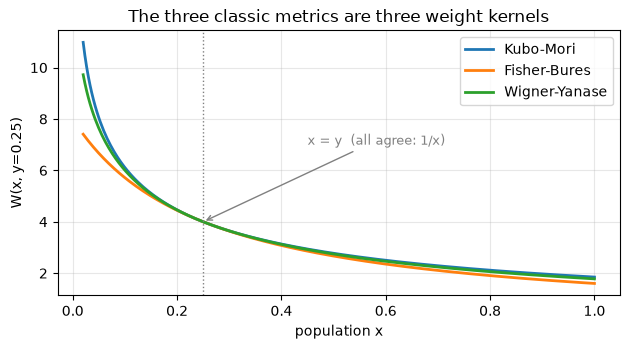

In [2]:
x = np.linspace(0.02, 1.0, 300)
y_fixed = 0.25
kernels = {
    "Kubo-Mori":     lambda x, y: (np.log(x) - np.log(y)) / (x - y + 1e-15),
    "Fisher-Bures":  lambda x, y: 2 / (x + y),
    "Wigner-Yanase": lambda x, y: 4 / (np.sqrt(x) + np.sqrt(y))**2,
}
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for name, f in kernels.items():
    ax.plot(x, f(x, y_fixed), lw=2, label=name)
ax.axvline(y_fixed, ls=":", c="grey", lw=1)
ax.annotate("x = y  (all agree: 1/x)", xy=(y_fixed, 1/y_fixed), xytext=(0.45, 7),
            arrowprops=dict(arrowstyle="->", color="grey"), color="grey", fontsize=9)
ax.set_xlabel("population x"); ax.set_ylabel(f"W(x, y={y_fixed})")
ax.set_title("The three classic metrics are three weight kernels")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 2 — one formula that contains them all

Wilde derives the information matrix arising from the **$\alpha$-$z$ Rényi relative
entropy** $D_{\alpha,z}$. Its kernel (Theorem 10) is

$$\zeta_{\alpha,z}(x,y)=\frac{z}{\alpha(1-\alpha)}\cdot\frac{x^{\frac{1-\alpha}{z}}-y^{\frac{1-\alpha}{z}}}{x-y}\cdot\frac{x^{\frac{\alpha}{z}}-y^{\frac{\alpha}{z}}}{x^{\frac1z}-y^{\frac1z}},\qquad \zeta_{\alpha,z}(x,x)=\frac1x .$$

Two knobs, $\alpha$ and $z$. Here is the punchline:

| classic metric | $(\alpha, z)$ |
|---|---|
| **Kubo–Mori** | $\alpha\to1$, *any* $z$ |
| **Fisher–Bures** | $(\tfrac12,\tfrac12)$ — sandwiched Rényi $\tfrac12$ |
| **Wigner–Yanase** | $(\tfrac12,1)$ — Petz–Rényi $\tfrac12$ |

Let's verify that on an actual thermal state, not just on paper.

In [3]:
rows = [("Kubo-Mori", "kubo_mori", 1.0, 1.0),
        ("Fisher-Bures", "fisher_bures", 0.5, 0.5),
        ("Wigner-Yanase", "wigner_yanase", 0.5, 1.0)]
print(f"{'metric':16s} {'(alpha, z)':14s}  max |named - AlphaZ|")
print("-" * 54)
for label, name, a, z in rows:
    err = np.max(np.abs(state.metric(name) - AlphaZ(a, z).matrix(state)))
    print(f"{label:16s} ({a}, {z}){'':6s}  {err:.2e}")
print("\n-> the three metrics qbmkit shipped with are all the SAME formula.")

metric           (alpha, z)      max |named - AlphaZ|
------------------------------------------------------
Kubo-Mori        (1.0, 1.0)        0.00e+00
Fisher-Bures     (0.5, 0.5)        1.11e-16
Wigner-Yanase    (0.5, 1.0)        4.44e-16

-> the three metrics qbmkit shipped with are all the SAME formula.


## Step 3 — the map: where does each metric live?

Now the useful picture. Every point $(\alpha,z)$ is a metric. Two special slices have
names of their own:

* $z=1$ → the **Petz–Rényi** family
* $z=\alpha$ → the **sandwiched Rényi** family

And not every point is legitimate: a metric is only *monotone* (obeys the
data-processing inequality — information cannot increase under a quantum channel) inside
a specific region, established by Zhang (2020) and quoted as Fact 9 in the paper:

$$0<\alpha<1,\; z\ge\max\{\alpha,1-\alpha\}\qquad\text{or}\qquad \alpha>1,\; \alpha-1\le z\le\alpha\le 2z .$$

`qbmkit` knows this region and **warns** you if you step outside it, so you never
silently use a non-monotone "metric".

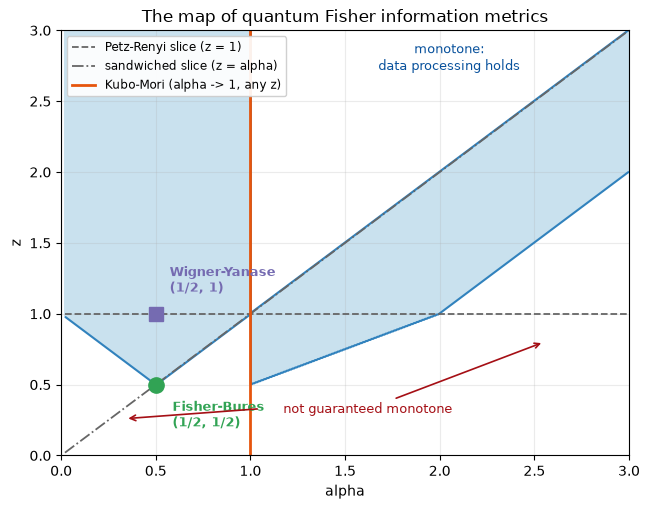

In [4]:
from qbm.metrics import alpha_z_is_monotone

A, Z = np.meshgrid(np.linspace(0.02, 3, 400), np.linspace(0.02, 3, 400))
ok = np.vectorize(alpha_z_is_monotone)(A, Z)

fig, ax = plt.subplots(figsize=(6.6, 5.2))
ax.contourf(A, Z, ok.astype(float), levels=[0.5, 1.5], colors=["#9ecae1"], alpha=0.55)
ax.contour(A, Z, ok.astype(float), levels=[0.5], colors=["#3182bd"], linewidths=1.5)

aa = np.linspace(0.02, 3, 200)
ax.plot(aa, np.ones_like(aa), "--", c="#666", lw=1.3, label="Petz-Renyi slice (z = 1)")
ax.plot(aa, aa, "-.", c="#666", lw=1.3, label="sandwiched slice (z = alpha)")
ax.axvline(1.0, color="#e6550d", lw=2, label="Kubo-Mori (alpha -> 1, any z)")

ax.plot(0.5, 0.5, "o", ms=11, c="#31a354", zorder=5)
ax.annotate("Fisher-Bures\n(1/2, 1/2)", (0.5, 0.5), textcoords="offset points",
            xytext=(12, -30), fontsize=9, color="#31a354", fontweight="bold")
ax.plot(0.5, 1.0, "s", ms=10, c="#756bb1", zorder=5)
ax.annotate("Wigner-Yanase\n(1/2, 1)", (0.5, 1.0), textcoords="offset points",
            xytext=(10, 16), fontsize=9, color="#756bb1", fontweight="bold")

ax.text(2.05, 2.72, "monotone:\ndata processing holds", fontsize=9.5, color="#08519c", ha="center")
# the non-monotone points are the WHITE wedges below the boundary
ax.annotate("not guaranteed monotone", xy=(2.55, 0.80), xytext=(1.62, 0.30),
            fontsize=9, color="#a50f15", ha="center",
            arrowprops=dict(arrowstyle="->", color="#a50f15", lw=1.2))
ax.annotate("", xy=(0.34, 0.26), xytext=(1.05, 0.33),
            arrowprops=dict(arrowstyle="->", color="#a50f15", lw=1.2))
ax.set_xlabel("alpha"); ax.set_ylabel("z")
ax.set_title("The map of quantum Fisher information metrics")
ax.set_xlim(0, 3); ax.set_ylim(0, 3)
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.92)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## Step 4 — the family is *ordered*

These are not an unstructured blob: the paper proves ordering relations in the
**Loewner order** ($A\preceq B$ means $B-A$ is positive semidefinite). Two of them:

* **Theorem 30** — the sandwiched-Rényi information matrix is *increasing* in $\alpha$.
* **Theorem 28** — the Petz–Rényi one *decreases* on $(0,\tfrac12]$ and *increases* on $[\tfrac12,\infty)$, so $\alpha=\tfrac12$ (Wigner–Yanase) sits at the **minimum**.

We can see both by tracking the size of the matrix along each slice.

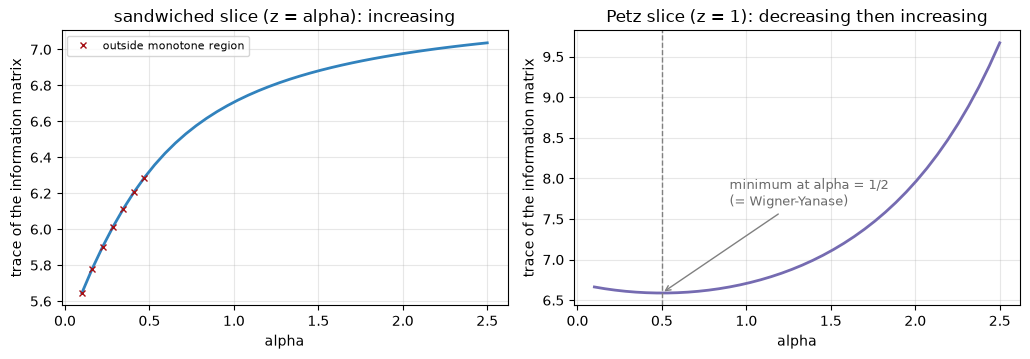

sandwiched increasing in the Loewner order: True


In [5]:
def curve(alphas, z_of_a):
    tr, ok = [], []
    for a in alphas:
        z = z_of_a(a)
        m = AlphaZ(a, z, check_monotone=False)
        tr.append(np.trace(m.matrix(state)))
        ok.append(alpha_z_is_monotone(a, z))
    return np.array(tr), np.array(ok)

alphas = np.linspace(0.1, 2.5, 40)
tr_sand, ok_sand = curve(alphas, lambda a: a)
tr_petz, ok_petz = curve(alphas, lambda a: 1.0)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.7))
axes[0].plot(alphas, tr_sand, lw=2, c="#3182bd")
axes[0].plot(alphas[~ok_sand], tr_sand[~ok_sand], "x", c="#a50f15", ms=5,
             label="outside monotone region")
axes[0].set_title("sandwiched slice (z = alpha): increasing")
axes[0].legend(fontsize=8)

axes[1].plot(alphas, tr_petz, lw=2, c="#756bb1")
axes[1].axvline(0.5, ls="--", c="grey", lw=1)
axes[1].annotate("minimum at alpha = 1/2\n(= Wigner-Yanase)", xy=(0.5, tr_petz.min()),
                 xytext=(0.9, tr_petz.min() + 0.35*(tr_petz.max()-tr_petz.min())),
                 arrowprops=dict(arrowstyle="->", color="grey"), fontsize=9, color="dimgrey")
axes[1].set_title("Petz slice (z = 1): decreasing then increasing")

for ax in axes:
    ax.set_xlabel("alpha"); ax.set_ylabel("trace of the information matrix"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# the ordering is a matrix statement, not just about the trace:
psd = lambda M: np.min(np.linalg.eigvalsh(M)) > -1e-9
mats = [AlphaZ(a, a, check_monotone=False).matrix(state) for a in (0.6, 0.8, 1.0, 1.5, 2.0)]
print("sandwiched increasing in the Loewner order:",
      all(psd(hi - lo) for lo, hi in zip(mats, mats[1:])))

## Step 5 — actually using them: quantum natural gradient

Any member of the family drops straight into the optimizer. The metric preconditions
the update,

$$\theta \leftarrow \theta - \eta\,(g+\lambda I)^{-1}\nabla L,$$

so a different geometry is a different *step direction*. Below we estimate a
transverse-field-Ising ground-state energy with several choices.

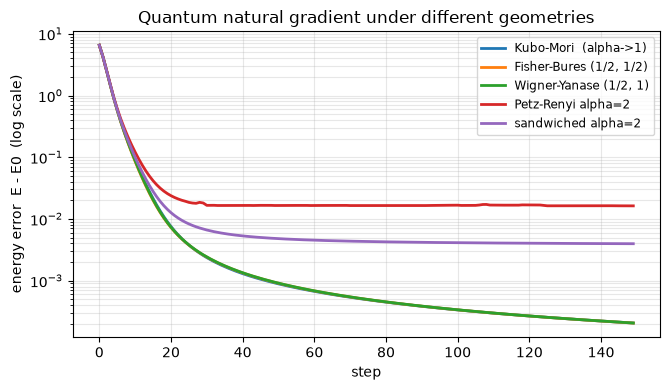

  Kubo-Mori  (alpha->1)      final error = 2.06e-04
  Fisher-Bures (1/2, 1/2)    final error = 2.05e-04
  Wigner-Yanase (1/2, 1)     final error = 2.06e-04
  Petz-Renyi alpha=2         final error = 1.63e-02
  sandwiched alpha=2         final error = 3.97e-03


In [6]:
H  = qbm.hamiltonians.tfim(4, J=1.0, g=1.5)
e0 = qbm.oracles.ground_energy(H)

def run(metric, lr=0.2, steps=150):
    m = qbm.FullyVisibleQBM(n=4)
    m.theta = np.random.default_rng(0).normal(scale=0.05, size=m.n_params)
    h = qbm.fit(m, qbm.losses.Energy(H),
                qbm.optim.NaturalGradient(metric=metric, lr=lr, reg=1e-3), steps=steps)
    return np.array(h.loss) - e0

curves = {
    "Kubo-Mori  (alpha->1)":      run("kubo_mori"),
    "Fisher-Bures (1/2, 1/2)":    run("fisher_bures"),
    "Wigner-Yanase (1/2, 1)":     run("wigner_yanase"),
    "Petz-Renyi alpha=2":         run(PetzRenyi(2.0)),
    "sandwiched alpha=2":         run(SandwichedRenyi(2.0)),
}
plt.figure(figsize=(6.8, 4.0))
for label, c in curves.items():
    plt.semilogy(np.clip(c, 1e-12, None), lw=2, label=label)
plt.xlabel("step"); plt.ylabel("energy error  E - E0  (log scale)")
plt.title("Quantum natural gradient under different geometries")
plt.legend(fontsize=8.5); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for label, c in curves.items():
    print(f"  {label:26s} final error = {c[-1]:.2e}")

All of them converge — the geometry changes the *path*, not the fixed point. That is
exactly what you want: the metric is a preconditioner, and which one is best is an
empirical question you can now actually ask.

## Step 6 — beyond the family: bring your own kernel

Nothing restricts you to $\alpha$-$z$. `CustomMetric` takes any $W(x,y)$. For a
*monotone* metric it should be $1/c(x,y)$ for an operator mean $c$ (the
Morozova–Chentsov / Petz classification) — but nothing is assumed, so you can also
explore non-standard choices deliberately.

In [7]:
geometric = CustomMetric(lambda x, y: 1 / np.sqrt(x * y), "geometric mean")
harmonic  = CustomMetric(lambda x, y: (x + y) / (2 * x * y), "harmonic mean")

print("custom kernels evaluate like any other metric:")
for m in (geometric, harmonic):
    g = m.matrix(state)
    print(f"  {m!r:34s} trace = {np.trace(g):7.4f}   PSD = {np.min(np.linalg.eigvalsh(g)) > -1e-9}")

# a nice consistency check: the geometric-mean kernel is exactly sandwiched-Renyi alpha=2
print("\ngeometric mean == SandwichedRenyi(2)? ",
      np.allclose(geometric.matrix(state), SandwichedRenyi(2.0).matrix(state), atol=1e-10))

custom kernels evaluate like any other metric:
  CustomMetric('geometric mean')     trace =  6.9766   PSD = True
  CustomMetric('harmonic mean')      trace =  7.9545   PSD = True

geometric mean == SandwichedRenyi(2)?  True


## Recap

* A quantum Fisher information metric **is** a weight kernel $W(x,y)$ on state
  derivatives — everything else in the pipeline is unchanged.
* The $\alpha$-$z$ family is one formula containing Kubo–Mori, Fisher–Bures,
  Wigner–Yanase, and the whole Petz-/sandwiched-Rényi families.
* The family is **ordered** and has a known **monotone region**; `qbmkit` warns you
  when you leave it.
* Any of them works with `NaturalGradient`, and `CustomMetric` lets you go outside the
  family entirely.

### How this is verified

Not by eyeballing. The test suite compares the Theorem-10 spectral formula against a
**finite-difference Hessian of $D_{\alpha,z}$ computed straight from its definition**,
agreeing to $\sim10^{-7}$ for $\alpha<1$ and $\alpha>1$ — an independent check of the
whole implementation — plus exact recovery of the three named metrics, the ordering
theorems above, positive semidefiniteness, and cross-backend agreement.
See `tests/test_alpha_z_metrics.py`.

### Where to go next

Use `AlphaZ` in a trainability study (does the barren-plateau picture depend on the
geometry?), or in a quantum Cramér–Rao analysis, where different metrics give different
achievable precision bounds.